# 0. Imports

In [35]:
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shap

try:
    from sklearnex import patch_sklearn
    patch_sklearn()
except ImportError:
    import warnings
    warnings.warn(
        "Intel(R) Extension for Scikit-learn is not installed." \
        "If using an intel CPU, consider installing it for potentially a ~10x speedup in model training and inference."
        "(pip install scikit-learn-intelex)")
    pass

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, GridSearchCV, StratifiedKFold, PredefinedSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV # type: ignore

plt.rcParams.update({'font.size': 8})
#plt.rcParams.update({'font.family': 'serif'})

proj = ccrs.PlateCarree()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# 1. Data

In [36]:
DATA_DIR = "../data/"
FIG_DIR = "../figures/"

LAT_LON = ["Lat", "Lon"]

RANDOM_SEED = 42

In [4]:
#LPJ-GUESS output
lpj_df = pl.read_csv(DATA_DIR + "LPJ-GUESS_output_BERN1.csv")
lpj_df = lpj_df.rename({col: col + f"_lpj" for col in lpj_df.columns if not col in LAT_LON})
lpj_df

Lon,Lat,NPP_lpj,SoilR_lpj,MaxBiomeCmax_lpj,MaxBiomeLAI_lpj,VegC_lpj,LitterC_lpj,SoilC_lpj,Biome_Cmax_lpj,Biome_LAI_lpj,Biome_obs_lpj
f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
39.75,-1.25,0.429,0.39,0.449,1.9821,1.225,0.758,5.941,8,12,12
150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
-63.75,82.75,0.0,0.0,0.0,0.0,0.0,0.003,0.002,13,13,17
59.25,30.75,0.043,0.042,0.09,0.2146,0.127,0.084,0.543,7,11,14
24.25,27.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13,13,17
…,…,…,…,…,…,…,…,…,…,…,…
114.75,34.75,0.35,0.307,3.389,2.5025,3.502,1.763,3.537,5,5,5
12.25,52.25,0.507,0.425,6.303,3.3822,6.785,4.612,12.687,5,5,5
-154.25,61.75,0.013,0.01,0.014,0.0951,0.014,0.097,1.207,11,11,17


In [5]:
# Grid information
grid_df = pl.read_csv(DATA_DIR + "gridlist_pan_gfed_ISO3_UN_ecoregion.txt", separator=' ')
grid_df = grid_df.rename({col: col + f"_grid" for col in grid_df.columns if not col in LAT_LON})
grid_df

Lon,Lat,GFED-region_grid,Pan_2007_grid,ISO3_grid,UN_grid,Ecoregion_grid
f64,f64,i64,str,str,i64,i64
-69.75,-55.25,5,"""Americas""","""CHL""",152,4
-69.25,-55.25,5,"""Americas""","""CHL""",152,4
-71.25,-54.75,5,"""Americas""","""CHL""",152,4
-70.75,-54.75,5,"""Americas""","""CHL""",152,4
-70.25,-54.75,5,"""Americas""","""CHL""",152,4
…,…,…,…,…,…,…
-73.75,79.75,1,"""Canada""","""CAN""",124,11
-73.25,79.75,1,"""Canada""","""CAN""",124,11
-72.75,79.75,1,"""Canada""","""CAN""",124,11


In [6]:
# Soil texture
soil_df = pl.read_csv(DATA_DIR + "soilmap.dat", separator="\t")
soil_df = soil_df.drop_nans().rename({"lon": "Lon", "lat": "Lat"})
soil_df = soil_df.rename({col: col + f"_soil" for col in soil_df.columns if not col in LAT_LON})
soil_df

Lon,Lat,clay_soil,silt_soil,sand_soil,orgC_soil,CN_soil,pH_soil,cellfraction_soil
f64,f64,f64,f64,f64,f64,f64,f64,f64
-179.75,71.25,0.08,0.37,0.55,0.02,11.0,5.9,0.482
-179.75,68.75,0.2,0.48,0.32,0.031,17.0,6.3,0.753
-179.75,68.25,0.2,0.48,0.32,0.031,17.0,6.3,0.447
-179.75,67.75,0.2,0.48,0.32,0.031,17.0,6.3,0.526
-179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.422
…,…,…,…,…,…,…,…,…
179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.455
179.75,66.75,0.2,0.48,0.32,0.031,17.0,6.3,0.408
179.75,66.25,0.2,0.48,0.32,0.031,17.0,6.3,0.597


In [7]:
# Load all climate datafiles and put in one dictionary
climate_files = {
    "tswrf": "Tswrfdaymean1961_1990.csv",
    "pre": "Predaymean1961_1990.csv",
    "tmp": "Tmpdaymean1961_1990.csv",
    "tmax": "Tmaxdaymean1961_1990.csv",
    "tmin": "Tmindaymean1961_1990.csv"
}

climate_df = {}
for name, path in climate_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    climate_df[name] = df

# Load all climate statistics datafiles and put in one dictionary
stats_files = {
    "tswrf": "Tswrfdaymean1961_1990_stats.csv",
    "pre": "Predaymean1961_1990_stats.csv",
    "tmp": "Tmpdaymean1961_1990_stats.csv",
    "tmax": "Tmaxdaymean1961_1990_stats.csv",
    "tmin": "Tmindaymean1961_1990_stats.csv"}

stats_df = {}
for name, path in stats_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    stats_df[name] = df

## 1.1 Merge dataframes

In [8]:
# Merge all dataframes on Lat and Lon
merged_df = lpj_df.join(grid_df, on=LAT_LON, how="inner").join(soil_df, on=LAT_LON, how="inner")

for name, df in stats_df.items():
    merged_df = merged_df.join(df, on=LAT_LON, how="inner")

In [9]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open(DATA_DIR + "legend of biomes.txt", 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [10]:
def drop_ground_truth(df):
    """Drops Lat, Lon, and all columns that end with '_lpj' or '_grid' from the dataframe."""
    return df.select([col for col in df.columns if not col.endswith(("_lpj", "_grid")) and col not in ["Lat", "Lon"]])

def drop_columns(df, str_in_columns_to_drop, keep_columns=[]):
    """Drops columns containing a specified string, except specified columns."""
    # Drop columns containing the specified string, except for those in keep_columns
    return df.select([col for col in df.columns if str_in_columns_to_drop not in col or col in keep_columns])

# 2. Data Description and Visualization
In this phase, provide an overview of the distribution of the outcome variables and select a
few key features for visualization. Present these insights using graphical representations
and a summary table of measures. You can refer to the RandomForestDemo notebook for
inspiration.

# 3. Binary Classification
In this part, you are going to build a binary classifier to classify two classes of biomes from
“Biome_obs”. You can choose one of the biomes and try to train a classifier that can distinguish this biome from the other data, e.g, ’Arctic/alpine tundra’ or ’not Arctic/alpine tundra’.
One way to narrow down the data if you have trouble creating the binary classifier is to
only include samples from two different country codes or regions.

In [11]:
arctic_str = "Arctic/alpine tundra"
arctic_index = biome_names.index(arctic_str) + 1

canada_df = merged_df.filter(pl.col("ISO3_grid") == "CAN")
russia_df = merged_df.filter(pl.col("ISO3_grid") == "RUS")

#### 3.1 Data Split
Split your dataset into two parts: a training set and a test set. The training set is used to
train the model, and the test set is used to evaluate model performance. Think through
how you split your data and what fits your purpose. Ways to split your data could be
through climate, zone, biome, countries or continents. Are all the biomes represented in
both your train and test data? Are the frequency of biome classes representative?

In [ ]:
y_canada = canada_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32) == arctic_index).to_numpy().flatten()
X_canada = drop_ground_truth(canada_df) # Removes Lat, Lon, and all columns that end with '_lpj' or '_grid' from the dataframe

X_train, X_canada_test, y_train, y_canada_test = train_test_split(X_canada, y_canada, test_size=0.2, random_state=RANDOM_SEED)

y_russia_test = russia_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32) == arctic_index).to_numpy().flatten()
X_russia_test = drop_ground_truth(russia_df)

#### 3.2. Model training
Next, train a Random Forest binary classification model. You can start by using training
data from one smaller region (could be one country code). Evaluate your model and try to
optimise the hyperparameters.

In [ ]:
# optimize hyperparameters on Nordics
nordics_df = merged_df.filter(pl.col("ISO3_grid").is_in(["DNK", "FIN", "ISL", "NOR", "SWE"]))
X_nordics = drop_ground_truth(nordics_df)
y_nordics = nordics_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32) == arctic_index).to_numpy().flatten()

# Define parameters to test in the grid search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4]}

cv = PredefinedSplit([-1] * len(X_train) + [0] * len(X_nordics))  # Use -1 for training data and 0 for validation data
best_params = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
).fit(
    pd.concat([X_train.to_pandas(), X_nordics.to_pandas()]), 
    np.concatenate([y_train, y_nordics])
).best_params_
print("Best hyperparameters found: ", best_params)

Fitting 1 folds for each of 36 candidates, totalling 36 fits
Best hyperparameters found:  {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}


In [ ]:
bin_class = RandomForestClassifier(random_state=RANDOM_SEED, **best_params)  # Use the best hyperparameters found
bin_class.fit(X_train, y_train) # Train the model on the training data

/home/hugowall/work/courses/BERN01/biome_project/.venv/lib64/python3.14/site-packages/sklearnex/_utils.py:160: UserWarning: Hyperparameters are static variables and can not be modified per instance.
  warnings.warn(
/home/hugowall/work/courses/BERN01/biome_project/.venv/lib64/python3.14/site-packages/sklearnex/_utils.py:175: UserWarning: Hyperparameters are static variables and can not be modified per instance.
  warnings.warn(
/home/hugowall/work/courses/BERN01/biome_project/.venv/lib64/python3.14/site-packages/sklearnex/_utils.py:160: UserWarning: Hyperparameters are static variables and can not be modified per instance.
  warnings.warn(
/home/hugowall/work/courses/BERN01/biome_project/.venv/lib64/python3.14/site-packages/sklearnex/_utils.py:175: UserWarning: Hyperparameters are static variables and can not be modified per instance.
  warnings.warn(


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

#### 3.3. Model evaluation
Evaluate the model's performance using appropriate metrics for binary classification. Common metrics include precision, recall, and to plot the predictions in a confusion matrix. Test
the model trained on one part of the world on the same biome in another part of the world,
e.g., Arctic/alpine tundra in either North America or Siberia. Does the model show equal
skill in both areas? Could the features you have chosen affect the skill of the model in another part of the world? Why?

In [24]:
score_train = bin_class.score(X_train, y_train)
score_canada_test = bin_class.score(X_canada_test, y_canada_test)
score_russia_test = bin_class.score(X_russia_test, y_russia_test)

print(f"Training score: {score_train:.4f}")
print(f"Test score (Canada): {score_canada_test:.4f}")
print(f"Test score (Russia): {score_russia_test:.4f}")

Training score: 0.9710
Test score (Canada): 0.9592
Test score (Russia): 0.8424


The scores above represents accuracy

In [25]:
print("\nClassification Report (Canada):")
print(classification_report(y_canada_test, bin_class.predict(X_canada_test), target_names=["Not Arctic", "Arctic"]))

print("\nClassification Report (Russia):")
print(classification_report(y_russia_test, bin_class.predict(X_russia_test), target_names=["Not Arctic", "Arctic"]))


Classification Report (Canada):
              precision    recall  f1-score   support

  Not Arctic       0.97      0.97      0.97      1003
      Arctic       0.91      0.92      0.91       297

    accuracy                           0.96      1300
   macro avg       0.94      0.94      0.94      1300
weighted avg       0.96      0.96      0.96      1300


Classification Report (Russia):
              precision    recall  f1-score   support

  Not Arctic       0.91      0.84      0.88      7810
      Arctic       0.73      0.84      0.78      3886

    accuracy                           0.84     11696
   macro avg       0.82      0.84      0.83     11696
weighted avg       0.85      0.84      0.84     11696



The score that was suggested to use in the lecture was F1. This is a combined measure of precision and recall.

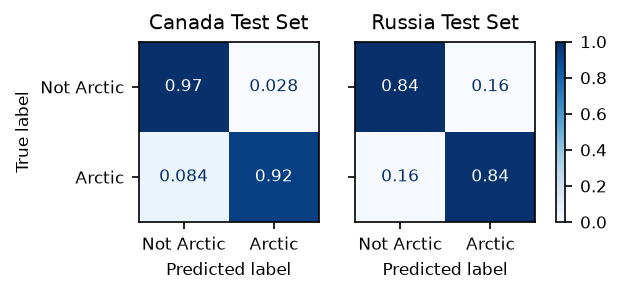

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(4, 1.85), sharey=True, layout="constrained", dpi=150)
ConfusionMatrixDisplay.from_estimator(
    bin_class, X_canada_test, y_canada_test, display_labels=['Not Arctic', 'Arctic'], cmap=plt.cm.Blues, normalize='true', ax=ax[0], colorbar=False)
ax[0].set_title("Canada Test Set")
ConfusionMatrixDisplay.from_estimator(
    bin_class, X_russia_test, y_russia_test, display_labels=['Not Arctic', 'Arctic'], cmap=plt.cm.Blues, normalize='true', ax=ax[1], colorbar=False)
ax[1].set_title("Russia Test Set")
ax[1].set_ylabel("")
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.05, pad=0.05)


# save the figure
plt.savefig(FIG_DIR + "bin_class_confusion_matrices.pdf", bbox_inches='tight')

#### 3.4. Feature importance and model interpretation
Analyze which features played the most crucial role in your model's decisions. Finally, discuss and interpret your results comprehensively, and explore any misclassifications to gain
valuable insights into how well machine learning models adapt to different continents and
environments. Are all features that you used for training necessary? Could you reduce the
number of features used? Were there features that you did not use that could be important? Why would they be important?

Optional: Plot the misclassified regions on a world map.

In [28]:
feature_imp = pd.DataFrame(
    {'importance':bin_class.feature_importances_},
    index=X_train.columns)
feature_imp = feature_imp.sort_values(by='importance', ascending=False)
print("\nFeature Importances:")
print(feature_imp.head(60))


Feature Importances:
                    importance
FallMean_tmp          0.083128
FallMedian_tmp        0.075544
FallMedian_tmax       0.068633
FallMean_tmax         0.066619
SummerMedian_tmin     0.055831
SummerMean_tmin       0.050421
FallMean_tmin         0.039345
SummerMean_tmp        0.034604
SummerMedian_tmax     0.034435
FallMean_tswrf        0.033731
SummerMean_tmax       0.033310
SummerMedian_tmp      0.032757
WinterMedian_tmax     0.030432
FallMedian_tmin       0.028506
SpringStd_tmin        0.025124
SpringStd_tmax        0.023427
SummerMean_tswrf      0.020590
FallMedian_tswrf      0.020485
WinterMean_tmin       0.020418
SpringStd_tmp         0.017380
WinterMean_tmax       0.017217
SpringMean_tmin       0.016675
WinterMedian_tmin     0.012937
SpringMedian_tswrf    0.011782
WinterMedian_tswrf    0.010141
SummerMedian_tswrf    0.009424
SpringMean_tmax       0.008881
SummerStd_tmp         0.008786
WinterMean_tmp        0.008505
SummerStd_tmin        0.008227
FallStd_tmax     

## Reduce features and fit new models

After looking at the heat correlation map of means and medians for the temperature in diferent seasons, we choose to remove the columns with medians before creating the model. They do not add any information. 

In [ ]:
# Remake the model without all features that have the work "median" in their name, as they are highly correlated with the mean features
X_train_red = drop_columns(X_train, "Median") # removes all columns that have the word "median" in their name
X_test_red = drop_columns(X_canada_test, "Median")

# Make a new model with the reduced feature set
bin_class2 = RandomForestClassifier(random_state=RANDOM_SEED, **best_params)  # Use the best hyperparameters found
bin_class2.fit(X_train_red, y_train) # Train the model on the training data

score_train2 = bin_class2.score(X_train_red, y_train)
score_test2 = bin_class2.score(X_test_red, y_canada_test)
print(f"Training score (all features): {score_train:.4f}")
print(f"Test score (all features): {score_canada_test:.4f}\n")

print(f"Training score (no median features): {score_train2:.4f}")
print(f"Test score (no median features): {score_test2:.4f}")

# Print classification report for the model without median features
print("\nClassification Report (no median features):")
print(classification_report(y_canada_test, bin_class2.predict(X_test_red), target_names=["Not Arctic", "Arctic"]))

# Print feature importances for the model without median features
feature_imp2 = pd.DataFrame(
    {'importance':bin_class2.feature_importances_},
    index=X_train_red.columns)
feature_imp2 = feature_imp2.sort_values(by='importance', ascending=False)
print("\nFeature Importances (no median features):")
print(feature_imp2.head(60))

Training score (all features): 0.9710
Test score (all features): 0.9592

Training score (no median features): 0.9683
Test score (no median features): 0.9615

Classification Report (no median features):
              precision    recall  f1-score   support

  Not Arctic       0.98      0.97      0.98      1003
      Arctic       0.91      0.92      0.92       297

    accuracy                           0.96      1300
   macro avg       0.94      0.95      0.95      1300
weighted avg       0.96      0.96      0.96      1300


Feature Importances (no median features):
                   importance
FallMean_tmp         0.131283
SummerMean_tmin      0.094649
FallMean_tmax        0.076368
FallMean_tmin        0.072332
SummerMean_tmax      0.069276
SpringStd_tmin       0.053977
FallMean_tswrf       0.050267
SummerMean_tmp       0.047363
SummerMean_tswrf     0.040553
SpringStd_tmp        0.034470
WinterMean_tmin      0.033447
SpringMean_tmin      0.031449
WinterMean_tmax      0.024289
SpringSt

Next, I will try to drop all soil columns that are below 0.0015 in feature importance. And make a new binary model from this.

In [ ]:
# Drop unwanted soil features (everything except ph_soil)
X_train_red = drop_columns(X_train_red, str_in_columns_to_drop="soil", keep_columns=["pH_soil"]) # removes all unwanted soil features
X_test_red = drop_columns(X_test_red, str_in_columns_to_drop="soil", keep_columns=["pH_soil"])

# Make a new model with the reduced feature set
bin_class3 = RandomForestClassifier(random_state=RANDOM_SEED, **best_params)  # Use the best hyperparameters found
bin_class3.fit(X_train_red, y_train) # Train the model on the training data

score_train3 = bin_class3.score(X_train_red, y_train)
score_test3 = bin_class3.score(X_test_red, y_canada_test)

print(f"Training score (median and soil features removed): {score_train3:.4f}")
print(f"Test score (median and soil features removed): {score_test3:.4f}")

# Print classification report for the model without median features
print("\nClassification Report (median and soil features removed):")
print(classification_report(y_canada_test, bin_class3.predict(X_test_red), target_names=["Not Arctic", "Arctic"]))

# Print feature importances for the model without median features
feature_imp3 = pd.DataFrame(
    {'importance':bin_class3.feature_importances_},
    index=X_train_red.columns)
feature_imp3 = feature_imp3.sort_values(by='importance', ascending=False)
print("\nFeature Importances (median and soil features removed):")
print(feature_imp3.head(60))

Training score (median and soil features removed): 0.9698
Test score (median and soil features removed): 0.9577

Classification Report (median and soil features removed):
              precision    recall  f1-score   support

  Not Arctic       0.97      0.97      0.97      1003
      Arctic       0.90      0.91      0.91       297

    accuracy                           0.96      1300
   macro avg       0.94      0.94      0.94      1300
weighted avg       0.96      0.96      0.96      1300


Feature Importances (median and soil features removed):
                  importance
FallMean_tmax       0.125736
FallMean_tmp        0.114081
SummerMean_tmin     0.087073
SummerMean_tmax     0.075263
FallMean_tmin       0.073942
SpringStd_tmin      0.069356
SummerMean_tmp      0.047551
FallMean_tswrf      0.046311
SummerMean_tswrf    0.036816
WinterMean_tmin     0.029144
SpringStd_tmp       0.027119
WinterMean_tmax     0.023016
SpringMean_tmin     0.022227
SpringStd_tmax      0.019780
SpringMean

This looks better. Will not try to improve this for now.

## Make plots

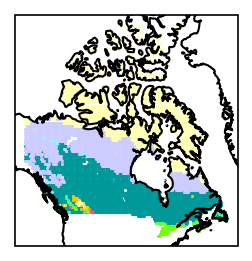

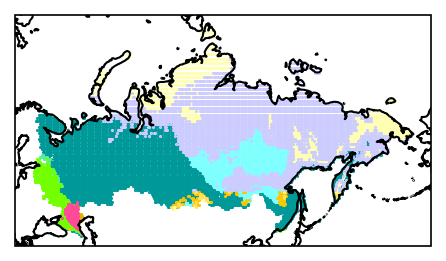

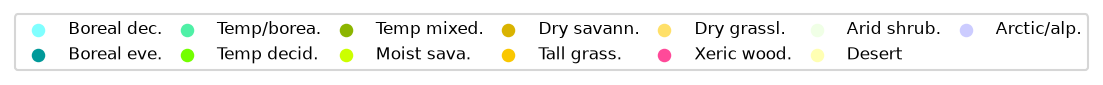

In [31]:
fig_size = (10, 2)
s = 0.25
dpi = 150

canada_mean_lon = canada_df.select(pl.col("Lon")).mean().item()
proj_canada = ccrs.Mercator(central_longitude=canada_mean_lon)
fig, ax = plt.subplots(figsize=fig_size, dpi=dpi, subplot_kw={"projection": proj_canada})

present_biomes_canada = canada_df.select("Biome_obs_lpj").unique().sort("Biome_obs_lpj").to_series().to_list()
for biome_id in present_biomes_canada:
    i = biome_id - 1
    name = biome_names[i]
    biome = canada_df.filter(pl.col("Biome_obs_lpj") == biome_id)
    ax.scatter(
        biome["Lon"].to_numpy(), 
        biome["Lat"].to_numpy(), 
        color=biome_rgbs[i],
        s=s, 
        transform=proj
        )

ax.coastlines()
plt.savefig(FIG_DIR + "biome_distribution_canada.pdf", bbox_inches='tight')
plt.show()


russia_mean_lon = russia_df.select(pl.col("Lon")).mean().item()
proj_russia = ccrs.Mercator(central_longitude=russia_mean_lon)
fig, ax = plt.subplots(figsize=fig_size, dpi=dpi, subplot_kw=dict(projection=proj_russia))

present_biomes_russia = russia_df.select("Biome_obs_lpj").unique().sort("Biome_obs_lpj").to_series().to_list()
for biome_id in present_biomes_russia:
    i = biome_id - 1
    name = biome_names[i]
    biome = russia_df.filter(pl.col("Biome_obs_lpj") == biome_id)
    ax.scatter(
        biome["Lon"].to_numpy(), 
        biome["Lat"].to_numpy(), 
        color=biome_rgbs[i],
        s=s, 
        transform=proj
        )

ax.coastlines()
plt.savefig(FIG_DIR + "biome_distribution_russia.pdf", bbox_inches='tight')
plt.show()

# render legend separately
fig, ax = plt.subplots(figsize=(0.1,0.1), dpi=dpi)

# take stable union
present_biomes = list(set(present_biomes_canada) | set(present_biomes_russia))
for biome_id in present_biomes:
    i = biome_id - 1
    name = biome_names[i]
    if len(name) > 10:
        name = name[:10] + "."
    ax.scatter([], [], color=biome_rgbs[i], label=name, s=30)
ax.axis('off')
legend = ax.legend(loc="center", ncols=7, columnspacing=0.5)
plt.savefig(FIG_DIR + "biome_distribution_legend.pdf", bbox_inches='tight')
plt.show()

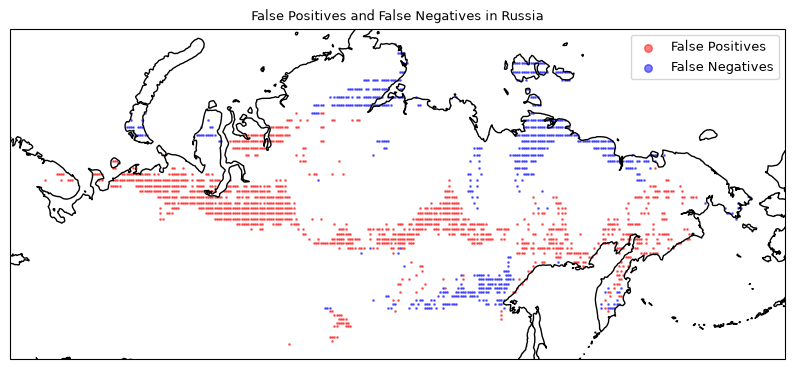

In [32]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

y_pred = bin_class.predict(X_russia_test)
fp = (y_pred == 1) & (y_russia_test == 0)
fn = (y_pred == 0) & (y_russia_test == 1)
fp_df = russia_df.filter(fp)
fn_df = russia_df.filter(fn)

ax.scatter(fp_df["Lon"].to_numpy(), fp_df["Lat"].to_numpy(), color="red", 
s=1, alpha=0.5, transform=proj, label="False Positives")
ax.scatter(fn_df["Lon"].to_numpy(), fn_df["Lat"].to_numpy(), color="blue", 
s=1, alpha=0.5, transform=proj, label="False Negatives")

ax.coastlines()

legend = ax.legend(fontsize=9)
for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.title("False Positives and False Negatives in Russia")
plt.show()

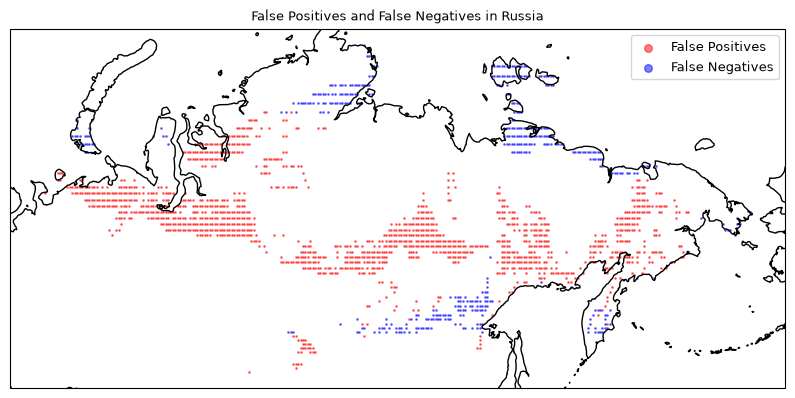

In [33]:
# Remake the same plot, but with the model that has median and soil features removed
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

X_test3 = X_russia_test[bin_class3.feature_names_in_] # Select only the features that were used in the model with median and soil features removed

y_pred3 = bin_class3.predict(X_test3)
fp = (y_pred3 == 1) & (y_russia_test == 0)
fn = (y_pred3 == 0) & (y_russia_test == 1)
fp_df = russia_df.filter(fp)
fn_df = russia_df.filter(fn)

ax.scatter(fp_df["Lon"].to_numpy(), fp_df["Lat"].to_numpy(), color="red", 
s=1, alpha=0.5, transform=proj, label="False Positives")
ax.scatter(fn_df["Lon"].to_numpy(), fn_df["Lat"].to_numpy(), color="blue", 
s=1, alpha=0.5, transform=proj, label="False Negatives")

ax.coastlines()

legend = ax.legend(fontsize=9)
for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.title("False Positives and False Negatives in Russia")
plt.show()

# 4. Multiclass classification
In this part, you are going to build two multiclass random forest classification models to
classify up to 18 biomes. You can use a combination of country code and region to build a
subset that you as a group would be interested in, e.g. South America, Europe, South-east
Asia et.c., again try to find another region where an interesting comparison can be made
and if your model are performing well on a different geographic region. For example boreal
Europe vs Canada, mainland USA (not including Alaska) vs. Australia or South America
vs. Africa. Important: Use “Biome_obs” as your target variable.

#### 4.1 Data split
Split your dataset into two parts: a training set, and a test set. The training set is used to
train the model, the validation set to tune hyperparameters, and the test set to evaluate
model performance.

In [ ]:
# Make new df with only european countries
europe_df = merged_df.filter(pl.col("GFED-region_grid") == 6)
    
# Remove biome 13 (Mediterranean forest, woodland, and scrub) from the dataset, 
# as it only has one observation in the dataset, which is not enough to train a model on
europe_df = europe_df.filter(pl.col("Biome_obs_lpj") != 13) 

# extract Biome_obs_lpj as y_train for europe_df
X = drop_ground_truth(europe_df)
y = europe_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32)).to_numpy().flatten()

# split europe_df into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y) # with stratify=y to ensure that the class distribution is similar in both train and test sets


#### 4.2 Model training
Next, train a Random Forest classification model using training data, and then put the
model on the test data.

In [ ]:
# Train a baseline model with default hyperparameters
multi_class = RandomForestClassifier(random_state=RANDOM_SEED)
multi_class.fit(X_train, y_train.flatten())

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [59]:
# evaluate the model on the test set
score_train = multi_class.score(X_train, y_train.flatten())
score_test = multi_class.score(X_test, y_test.flatten())
print("First simple model with default hyperparameters and all features:")
print(f"Training score: {score_train:.4f}")
print(f"Test score: {score_test:.4f}")

First simple model with default hyperparameters and all features:
Training score: 1.0000
Test score: 0.8351


In [60]:
print("\nClassification Report:")
target_names = [biome_names[i-1] for i in set(y_test.flatten())]
print(classification_report(y_test, multi_class.predict(X_test), target_names=target_names))


Classification Report:
                      precision    recall  f1-score   support

  Boreal ever forest       0.94      0.94      0.94       129
 Temp/boreal mix fo.       0.65      0.59      0.62        74
   Temp decid forest       0.84      0.88      0.86       247
 Temp broad ever fo.       0.81      0.88      0.85        34
   Temp mixed forest       0.43      0.30      0.35        10
      Moist savannas       0.00      0.00      0.00         1
        Dry savannas       0.88      1.00      0.93        21
       Dry grassland       0.50      1.00      0.67         1
    Xeric wood/shrub       0.93      0.81      0.86        31
              Desert       0.00      0.00      0.00         2
Arctic/alpine tundra       0.69      0.64      0.67        14

            accuracy                           0.84       564
           macro avg       0.61      0.64      0.61       564
        weighted avg       0.83      0.84      0.83       564



/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## 4.3 Hyper-parameter Tuning
Use cross-validation to tune hyperparameters like the number of trees, tree depth, and
minimum leaf samples. This step can help improve model performance. If you encounter
issues with runtime, consider narrowing your focus to fewer geographic regions. It is also
possible to sample the grid list with the .sample() function on Pandas DataFrames, in that
case, make sure to sample only the training dataset and not the full dataset.

In [ ]:
# Define parameters to test in the grid search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
rf = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)

# Run grid search to find the best hyperparameters
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 50}
Best CV accuracy: 0.8428


In [65]:
# Train a new model with the best hyperparameters found in the grid search
multi_class_tuned = grid_search.best_estimator_
print("Tuned model trained with best hyperparameters (compared with default hyperparameters):")
print(f"Training score default parameters: {score_train:.4f}")
print(f"Test score default parameters: {score_test:.4f}\n")
print(f"Training accuracy tuned hyperparameters: {multi_class_tuned.score(X_train, y_train):.4f}")
print(f"Test accuracy tuned hyperparameters: {multi_class_tuned.score(X_test, y_test):.4f}")

Tuned model trained with best hyperparameters (compared with default hyperparameters):
Training score default parameters: 1.0000
Test score default parameters: 0.8351

Training accuracy tuned hyperparameters: 0.9565
Test accuracy tuned hyperparameters: 0.8351


## 4.4. Model Evaluation
Evaluate the model's performance using appropriate metrics for multiclass classification.



In [66]:
from sklearn.metrics import balanced_accuracy_score, f1_score, log_loss, cohen_kappa_score

metrics_multi = [] #list to save the values

#evaluate both the baseline and tuned models on the test set and save the metrics
for name, model in {"Baseline": multi_class, "Tuned": multi_class_tuned}.items(): 
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    metrics_multi.append({"model": name,
                        "accuracy": accuracy_score(y_test, y_pred),
                        "balanced accuracy":balanced_accuracy_score(y_test, y_pred),
                        "macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
                        "cross entropy": log_loss(y_test, y_prob, labels=model.classes_),
                        "Cohen's kappa": cohen_kappa_score(y_test, y_pred)})

display(pd.DataFrame(metrics_multi).set_index("model"))

#print classification report for the tuned multi-class model
labels = multi_class_tuned.classes_
names = [biome_names[i-1] for i in labels]
print(classification_report(y_test, multi_class_tuned.predict(X_test), labels=labels, 
                            target_names=names, zero_division=0))

,accuracy,balanced accuracy,macro F1,cross entropy,Cohen's kappa
model,,,,,
Baseline,0.835106,0.640253,0.613233,0.535319,0.772038
Tuned,0.835106,0.536472,0.544449,0.553181,0.769930


                      precision    recall  f1-score   support

  Boreal ever forest       0.92      0.95      0.93       129
 Temp/boreal mix fo.       0.69      0.55      0.62        74
   Temp decid forest       0.84      0.90      0.87       247
 Temp broad ever fo.       0.83      0.85      0.84        34
   Temp mixed forest       0.43      0.30      0.35        10
      Moist savannas       0.00      0.00      0.00         1
        Dry savannas       0.88      1.00      0.93        21
       Dry grassland       0.00      0.00      0.00         1
    Xeric wood/shrub       0.89      0.77      0.83        31
              Desert       0.00      0.00      0.00         2
Arctic/alpine tundra       0.67      0.57      0.62        14

            accuracy                           0.84       564
           macro avg       0.56      0.54      0.54       564
        weighted avg       0.82      0.84      0.83       564



## 4.5. Features Importance
Analyze which features played the most crucial role in your model's decisions. What happens when you are limiting the number of features? Also, are there any auto-correlations
in the feature data?

In [34]:
# Print feature importances for the tuned multi-class model
feature_imp_tuned = pd.DataFrame(
    {'importance':multi_class_tuned.feature_importances_},
    index=X_train.columns)
feature_imp_tuned = feature_imp_tuned.sort_values(by='importance', ascending=False) 

print("\nFeature Importances (tuned multi-class model):")
print(feature_imp_tuned.head(60))


Feature Importances (tuned multi-class model):
                    importance
SummerMean_tmin       0.051240
FallMean_tmp          0.045665
WinterMean_tmp        0.044329
FallMean_tmin         0.040536
SpringMean_tmp        0.038252
WinterMedian_tmp      0.037117
SummerMedian_tmp      0.036703
SummerMean_tmp        0.035073
SummerMean_tmax       0.032540
WinterMean_tswrf      0.032488
SpringMean_tswrf      0.029703
WinterMean_tmax       0.028499
FallMedian_tmp        0.028319
SummerMedian_tmin     0.026156
SpringMedian_tmp      0.025932
FallMean_tmax         0.025636
SummerMedian_tmax     0.024671
SpringMean_tmax       0.020725
WinterMedian_tmin     0.018750
FallMedian_tmin       0.018528
FallMedian_tmax       0.018453
WinterMean_tmin       0.017040
WinterMedian_tmax     0.015349
SpringMedian_tmax     0.013692
SpringMedian_tswrf    0.012424
WinterMedian_tswrf    0.011830
FallStd_pre           0.011636
FallMedian_pre        0.011560
FallMean_pre          0.010948
WinterStd_tmin        

In [35]:
[f for f in X_train.columns if "soil" in f] # are there any soil features in the model? 

feature_importance = pd.Series(multi_class_tuned.feature_importances_, index=X_train.columns)
print(feature_importance[feature_importance.index.str.contains("soil")].sort_values(ascending=False))

sand_soil            0.004045
cellfraction_soil    0.003858
pH_soil              0.002511
clay_soil            0.002510
orgC_soil            0.002137
silt_soil            0.001743
CN_soil              0.001652
dtype: float64


These soil features have too small feature importance to be shown in the longer list above. Candidates to remove when improving the model. Also try to remove the medians as in the previous binary model. 

In [ ]:
# Remake the model without all features that have the work "median" in their name
X_train_red = drop_columns(X_train, "Median") # removes all columns that have the word "median" in their name
X_test_red = drop_columns(X_test, "Median")

# Make a new model with the reduced feature set
multi_class2 = RandomForestClassifier(random_state=RANDOM_SEED, max_depth=5, n_estimators=100) 
multi_class2.fit(X_train_red, y_train) # Train the model on the training data

score_train2 = multi_class2.score(X_train_red, y_train)
score_test2 = multi_class2.score(X_test_red, y_test)
print(f"Training score (all features): {score_train:.4f}")
print(f"Test score (all features): {score_test:.4f}\n")

print(f"Training score (no median or soil features): {score_train2:.4f}")
print(f"Test score (no median or soil features): {score_test2:.4f}")

# Print classification report for the model without median features
print("\nClassification Report (no median or soil features):")
print(classification_report(y_test, multi_class2.predict(X_test_red)))

# Print feature importances for the model without median features
feature_imp2 = pd.DataFrame(
    {'importance':multi_class2.feature_importances_},
    index=X_train_red.columns)
feature_imp2 = feature_imp2.sort_values(by='importance', ascending=False)
print("\nFeature Importances (no median or soil features):")
print(feature_imp2.head(60))

Training score (all features): 1.0000
Test score (all features): 0.8351

Training score (no median or soil features): 0.8561
Test score (no median or soil features): 0.8333

Classification Report (no median or soil features):
              precision    recall  f1-score   support

           2       0.91      0.95      0.93       129
           3       0.90      0.35      0.50        74
           5       0.79      0.97      0.87       247
           6       0.78      0.91      0.84        34
           7       0.00      0.00      0.00        10
          11       0.00      0.00      0.00         1
          12       0.88      1.00      0.93        21
          14       0.00      0.00      0.00         1
          15       1.00      0.77      0.87        31
          17       0.00      0.00      0.00         2
          18       0.60      0.43      0.50        14

    accuracy                           0.83       564
   macro avg       0.53      0.49      0.50       564
weighted avg    

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

### Redo hyper parameter testing for the model with median and soil features removed

In [ ]:
# Define parameters to test in the grid search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
rf = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)

# Run grid search to find the best hyperparameters
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train_red, y_train) # use the reduced feature set for the grid search
print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV accuracy: 0.8433


In [71]:
# Train a new model with the best hyperparameters found in the grid search
multi_class2_tuned = grid_search.best_estimator_
# add printouts on the untuned model for comparison
print(f"Training accuracy (untuned hyperparameters, medians removed): {multi_class2.score(X_train_red, y_train):.4f}")
print(f"Test accuracy (untuned hyperparameters, medians removed): {multi_class2.score(X_test_red, y_test):.4f}\n")
print(f"Training accuracy (tuned hyperparameters, medians removed): {multi_class2_tuned.score(X_train_red, y_train):.4f}")
print(f"Test accuracy (tuned hyperparameters, medians removed): {multi_class2_tuned.score(X_test_red, y_test):.4f}")

Training accuracy (untuned hyperparameters, medians removed): 0.8561
Test accuracy (untuned hyperparameters, medians removed): 0.8333

Training accuracy (tuned hyperparameters, medians removed): 0.9871
Test accuracy (tuned hyperparameters, medians removed): 0.8351


Here we are getting the same test accuracy as with all features. It is worse if we also remove the soil features. Will stop here.

### Feature importance in the new model

In [43]:
# Print feature importances for the tuned multi-class model
feature_imp_tuned = pd.DataFrame(
    {'importance':multi_class2_tuned.feature_importances_},
    index=X_train_red.columns)
feature_imp_tuned = feature_imp_tuned.sort_values(by='importance', ascending=False) 

print("\nFeature Importances (tuned multi-class model):")
print(feature_imp_tuned.head(60))


Feature Importances (tuned multi-class model):
                   importance
SummerMean_tmp       0.073269
FallMean_tmp         0.068896
SummerMean_tmin      0.065500
WinterMean_tmp       0.061130
SpringMean_tswrf     0.057827
FallMean_tmin        0.048115
WinterMean_tmin      0.045887
SummerMean_tmax      0.044981
FallMean_tmax        0.043442
WinterMean_tswrf     0.038906
FallMean_pre         0.034339
SpringMean_tmax      0.031788
SpringMean_tmp       0.031280
WinterMean_tmax      0.025982
SummerMean_tswrf     0.021830
FallMean_tswrf       0.016342
SummerMean_pre       0.015413
SpringStd_tmax       0.015112
SummerStd_tswrf      0.014142
FallStd_pre          0.013985
WinterStd_tswrf      0.013965
SpringStd_tmin       0.013954
SpringMean_tmin      0.012594
SpringStd_pre        0.012589
SpringStd_tmp        0.011859
FallStd_tmin         0.011679
WinterStd_tmax       0.011276
WinterStd_tmin       0.011004
WinterMean_pre       0.010675
SpringMean_pre       0.010118
SummerStd_tmp        0

## Make plots

<Figure size 1000x1000 with 0 Axes>

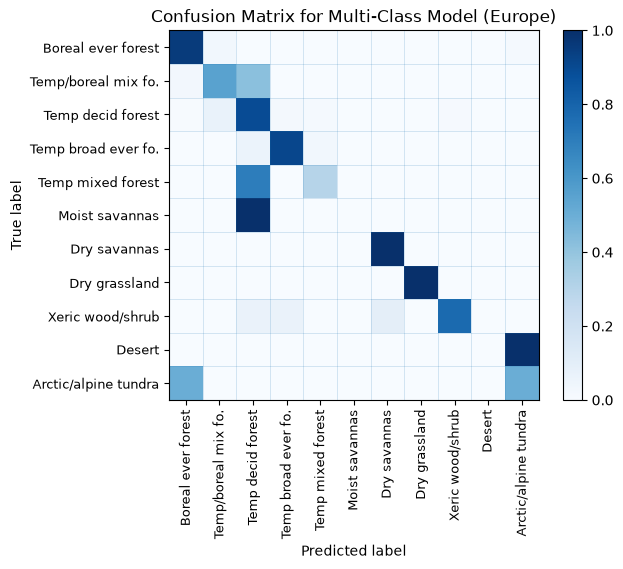

In [72]:
# Get the target names for the classes in the model
model_target_names = [biome_names[i - 1] for i in multi_class2_tuned.classes_]

# Make confusion matrix for the tuned multi-class model
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_estimator(
    multi_class2_tuned, X_test_red, y_test, display_labels=model_target_names, 
    cmap=plt.cm.Blues, normalize="true", include_values=False)
disp.ax_.tick_params(axis="both", labelsize=9)
for i in range(len(model_target_names) + 1):
    disp.ax_.axvline(i - 0.5, linewidth=0.4, alpha=0.3)
    disp.ax_.axhline(i - 0.5, linewidth=0.4, alpha=0.3)
plt.xticks(rotation=90)
disp.ax_.set_title("Confusion Matrix for Multi-Class Model (Europe)", fontsize=12)
plt.show()

<Figure size 1000x1000 with 0 Axes>

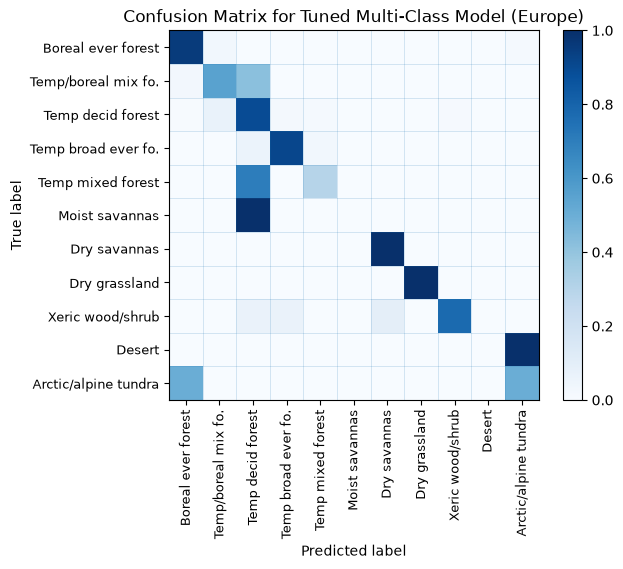

In [73]:
# Get the target names for the classes in the model
model_target_names = [biome_names[i - 1] for i in multi_class2_tuned.classes_]

# Make confusion matrix for the tuned multi-class model
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_estimator(
    multi_class2_tuned, X_test_red, y_test, display_labels=model_target_names, 
    cmap=plt.cm.Blues, normalize="true", include_values=False)
disp.ax_.tick_params(axis="both", labelsize=9)
for i in range(len(model_target_names) + 1):
    disp.ax_.axvline(i - 0.5, linewidth=0.4, alpha=0.3)
    disp.ax_.axhline(i - 0.5, linewidth=0.4, alpha=0.3)
plt.xticks(rotation=90)
disp.ax_.set_title("Confusion Matrix for Tuned Multi-Class Model (Europe)", fontsize=12)
plt.show()


Comment: Some of the diagonal boxes are very light. This indicates that the model has low recall for that biome, i.e. it was bad at predicting that biome correctly. Could depend on few observations for that biome or that it is hard to distinguish from other biomes. 

It seems like tall grassland is predicted as boreal ever forest or arctic tundra.

## 4.6. Compare LPJ-GUESS model and machine learning model
Compare your trained against the biomes estimated by LPJ-GUESS for “Biome_Cmax”
and Biome_LAI. Discuss the difference in prediction between the LPJ-GUESS outputs and
the machine learning model outputs. Where do the models agree and where do the model
predictions diverge? Why?

In [ ]:
# Compare the tuned multi-class model with the LPJ-GUESS model
y_plus = europe_df["Biome_obs_lpj"].cast(pl.Int32).to_numpy()

# Split the data into training and testing sets to get the test_df for LPJ-GUESS predictions
_, idx_test = train_test_split(np.arange(len(y_plus)), test_size=0.2, random_state=RANDOM_SEED, stratify=y_plus)
test_df = europe_df[idx_test]

# Collect the observed values and predictions from both models
obs = y_test
preds = {"RF tuned": multi_class_tuned.predict(X_test),
        "LPJ Cmax": test_df["Biome_Cmax_lpj"].cast(pl.Int32).to_numpy(),
        "LPJ Lai": test_df["Biome_LAI_lpj"].cast(pl.Int32).to_numpy()}

# Evaluate the models and store the metrics in a list of dictionaries
metrics_comp = []
for name, p in preds.items():
    metrics_comp.append({"model": name,
                        "accuracy": accuracy_score(obs, p),
                        "macro F1": f1_score(obs, p, average="macro", labels=np.unique(obs)),
                        "Cohen's kappa": cohen_kappa_score(obs, p)})
display(pd.DataFrame(metrics_comp).set_index("model"))

,accuracy,macro F1,Cohen's kappa
model,,,
RF tuned,0.835106,0.544449,0.769930
LPJ Cmax,0.570922,0.142835,0.396783
LPJ Lai,0.510638,0.127850,0.330336


 - RF tuned: our tuned multi class model
 - LPJ Cmax: LJP guess outputs (what this model predicts)
 - LPJ Lai: Leaf area index

In [81]:
print("Agreement between the tuned multi-class model and LPJ-GUESS predictions:")
print("RF vs. Cmax:", (preds["RF tuned"]==preds["LPJ Cmax"]).mean())
print("RF vs. Lai:", (preds["RF tuned"]==preds["LPJ Lai"]).mean())

Agreement between the tuned multi-class model and LPJ-GUESS predictions:
RF vs. Cmax: 0.5921985815602837
RF vs. Lai: 0.524822695035461


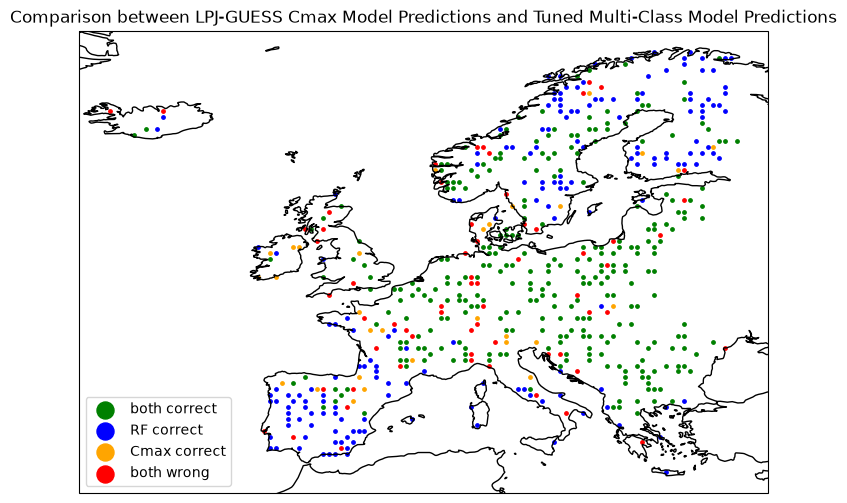

In [92]:
# Create a scatter plot of the predictions from the tuned multi-class model and the LPJ-GUESS for Cmax model
rf_preds, cmax_preds, lai_preds = preds["RF tuned"], preds["LPJ Cmax"], preds["LPJ Lai"]
cats_cmax = {"both correct": ("green", (rf_preds==obs) & (cmax_preds==obs)),
            "RF correct": ("blue", (rf_preds==obs) & (cmax_preds!=obs)),
            "Cmax correct": ("orange", (rf_preds!=obs) & (cmax_preds==obs)),
            "both wrong": ("red", (rf_preds!=obs) & (cmax_preds!=obs))}
lon, lat = test_df["Lon"].to_numpy(), test_df["Lat"].to_numpy()
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw=dict(projection=proj))
for label, (color, m) in cats_cmax.items():
    ax.scatter(lon[m], lat[m], s=6, color=color, label=label, transform=proj)
ax.coastlines()
ax.legend(markerscale=5)
ax.set_title("Comparison between LPJ-GUESS Cmax Model Predictions and Tuned Multi-Class Model Predictions")
plt.show()

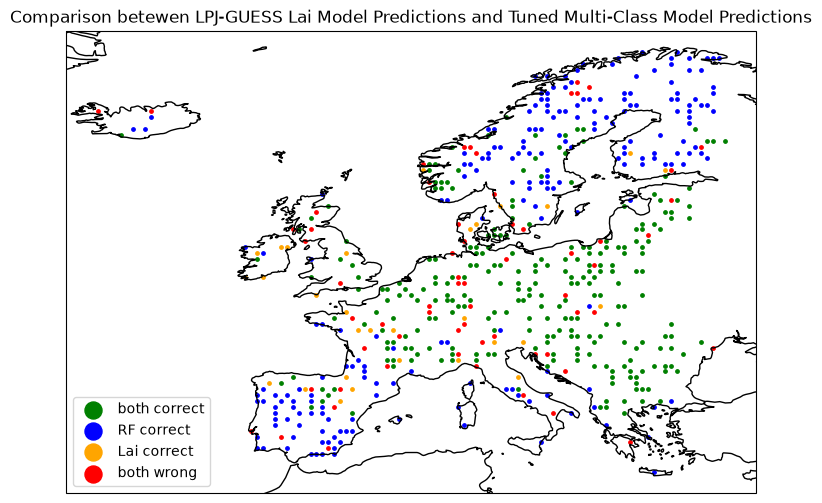

In [ ]:
# Repeating the same scatter plot, but for the LPJ-GUESS Lai model
cats_lai = {"both correct": ("green", (rf_preds==obs) & (lai_preds==obs)),
            "RF correct": ("blue", (rf_preds==obs) & (lai_preds!=obs)),
            "Lai correct": ("orange", (rf_preds!=obs) & (lai_preds==obs)),
            "both wrong": ("red", (rf_preds!=obs) & (lai_preds!=obs))}

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw=dict(projection=proj))
for label, (color, m) in cats_lai.items():
    ax.scatter(lon[m], lat[m], s=6, color=color, label=label, transform=proj)
ax.coastlines()
ax.legend(markerscale=5)
ax.set_title("Comparison between LPJ-GUESS Lai Model Predictions and Tuned Multi-Class Model Predictions")
plt.show()

## Test Europe model on Russia

In [96]:
# split the Russia dataset into X and y
y_test = russia_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32)).to_numpy().flatten()
X_test = drop_ground_truth(russia_df)
X_test_red = drop_columns(X_test, "Median") # removes all columns that have the word "median" in their name

# evaluate the tuned multi-class model on the Russia dataset
score_russia = multi_class2_tuned.score(X_test_red, y_test)
print(f"Test score on Russia dataset: {score_russia:.4f}")

Test score on Russia dataset: 0.3337


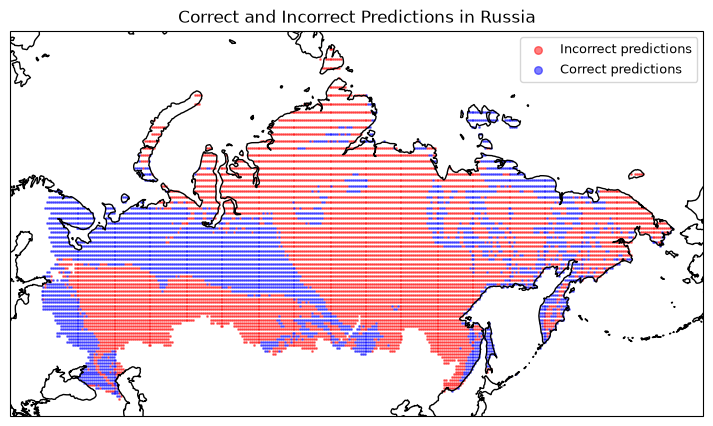

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

# Predictions from the new multi-class model
y_pred = multi_class2_tuned.predict(X_test_red)

# Correct and incorrect predictions
correct = y_pred == y_test
incorrect = y_pred != y_test

# Filter the Russia dataframe
correct_df = russia_df.filter(correct)
incorrect_df = russia_df.filter(incorrect)

# Plot incorrect predictions
ax.scatter(
    incorrect_df["Lon"].to_numpy(),
    incorrect_df["Lat"].to_numpy(),
    color="red",
    s=1,
    alpha=0.5,
    transform=proj,
    label="Incorrect predictions")

# Plot correct predictions
ax.scatter(
    correct_df["Lon"].to_numpy(),
    correct_df["Lat"].to_numpy(),
    color="blue",
    s=1,
    alpha=0.5,
    transform=proj,
    label="Correct predictions")

ax.coastlines()
legend = ax.legend(fontsize=9)
for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.title("Correct and Incorrect Predictions in Russia")
plt.show()

# 5. Regression

In this part, you are going to build two random forest regression models to predict two continuous variables. One model to predict “NPP” and another to predict “VegC”. Split the data similar to section 4.1. and train your regression models on the training data.

In [ ]:
# Splitting the data into train and test sets for regression models as in 4.1
X_reg = drop_ground_truth(europe_df)
y_npp = europe_df["NPP_lpj"].to_numpy()
y_vegC = europe_df["VegC_lpj"].to_numpy()

# Splitting the data into train and test sets for europe_df, but we don't need to stratify the data, as NPP and VegC are continuous variables
X_reg_train, X_reg_test, y_npp_train, y_npp_test, y_vegC_train, y_vegC_test = train_test_split(
    X_reg, y_npp, y_vegC, test_size=0.2, random_state=RANDOM_SEED)

In [ ]:
# Train a Random Forest Regressor for NPP and VegC
model_reg_NPP = RandomForestRegressor(random_state=RANDOM_SEED)
model_reg_NPP.fit(X_reg_train, y_npp_train)

model_reg_VegC = RandomForestRegressor(random_state=RANDOM_SEED)
model_reg_VegC.fit(X_reg_train, y_vegC_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [104]:
# Evaluate the models on the training and test sets
score_reg_NPP_train = model_reg_NPP.score(X_reg_train, y_npp_train)
score_reg_NPP_test = model_reg_NPP.score(X_reg_test, y_npp_test)

score_reg_VegC_train = model_reg_VegC.score(X_reg_train, y_vegC_train)
score_reg_VegC_test = model_reg_VegC.score(X_reg_test, y_vegC_test)

# Print the scores for the regression models
print(f"Training score for NPP regression: {score_reg_NPP_train:.4f}")
print(f"Test score for NPP regression: {score_reg_NPP_test:.4f}\n")
print(f"Training score for VegC regression: {score_reg_VegC_train:.4f}")
print(f"Test score for VegC regression: {score_reg_VegC_test:.4f}")

Training score for NPP regression: 0.9779
Test score for NPP regression: 0.8780

Training score for VegC regression: 0.9603
Test score for VegC regression: 0.7554


## 5.1 Model Evaluation

Evaluate the model's performance using appropriate metrics for regression, such as mean
squared error.

In [105]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate the regression models and save the metrics
targets = [("NPP", model_reg_NPP, y_npp_train, y_npp_test), 
           ("VegC", model_reg_VegC, y_vegC_train, y_vegC_test)]

reg_comp = [] # List to save the values

# Evaluate both the NPP and VegC regression models on the test set and save the metrics
for name, model, ytr, yte in targets:
    y_pred = model.predict(X_reg_test)
    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    reg_comp.append({"model": name,
                    "MSE": mean_squared_error(yte, y_pred),
                    "MAE": mean_absolute_error(yte, y_pred),
                    "train R2": r2_score(ytr, model.predict(X_reg_train)),
                    "test R2": r2_score(yte, y_pred),
                    "RMSE": rmse}) #Q: Should we add cross entropy and Cohen's kappa for regression models? A: No, those metrics are not applicable to regression models.

display(pd.DataFrame(reg_comp).set_index("model"))

,MSE,MAE,train R2,test R2,RMSE
model,,,,,
NPP,0.002116,0.027681,0.977891,0.877992,0.045997
VegC,2.060492,1.015676,0.960257,0.755419,1.435441


In [ ]:
# Evaluate the regression models per biome on the test set
_, idx_test = train_test_split(np.arange(len(y_plus)), test_size=0.2, random_state=RANDOM_SEED)
biome_test = europe_df["Biome_obs_lpj"].to_numpy()[idx_test]

# Evaluate both the NPP and VegC regression models on the test set and save the metrics per biome
for name, model, ytr, yte in targets:
    y_pred = model.predict(X_reg_test)
    df = pd.DataFrame({"biome": biome_test, "obs": yte, "pred": y_pred})
    df["abs_err"] = np.abs(df["pred"] - df["obs"])
    df["sq_err"] = (df["pred"] - df["obs"])**2
    df_out = df.groupby("biome").agg(n=("obs", "size"),
                                     mean_obs=("obs", "mean"),
                                     mean_pred=("pred", "mean"),
                                     MAE = ("abs_err", "mean"),
                                     MSE = ("sq_err", "mean"))

    df_out["RMSE"] = np.sqrt(df_out.pop("MSE"))
    df_out.index = [biome_names[i-1] for i in df_out.index]
    print(f"\n{name}: errors per biome on the test set")
    display(df_out)


NPP: errors per biome on the test set


,n,mean_obs,mean_pred,MAE,RMSE
Boreal ever forest,113,0.593805,0.587852,0.045240,0.072207
Temp/boreal mix fo.,83,0.610398,0.597471,0.025653,0.030991
Temp decid forest,254,0.518173,0.522478,0.017015,0.021873
Temp broad ever fo.,18,0.467111,0.468206,0.022926,0.028919
Temp mixed forest,13,0.512154,0.506088,0.022472,0.030668
Moist savannas,1,0.366000,0.383130,0.017130,0.017130
Dry savannas,27,0.280704,0.285085,0.012969,0.017323
Xeric wood/shrub,30,0.314667,0.322916,0.018079,0.020986
Desert,3,0.004667,0.109027,0.104360,0.108278
Arctic/alpine tundra,22,0.243364,0.323469,0.096415,0.120378



VegC: errors per biome on the test set


,n,mean_obs,mean_pred,MAE,RMSE
Boreal ever forest,113,6.968637,6.948968,1.549811,2.115151
Temp/boreal mix fo.,83,8.233639,8.617889,1.357362,1.776571
Temp decid forest,254,7.844114,7.685808,0.861892,1.104687
Temp broad ever fo.,18,5.990278,5.934919,0.819476,1.012133
Temp mixed forest,13,6.843000,7.375883,0.718208,0.980503
Moist savannas,1,3.882000,4.393260,0.511260,0.511260
Dry savannas,27,1.573741,1.620308,0.187511,0.268266
Xeric wood/shrub,30,3.265000,3.264622,0.342818,0.463195
Desert,3,0.006000,0.504510,0.498510,0.718444
Arctic/alpine tundra,22,0.355409,1.461577,1.122259,1.406385


## 5.2 Feature Importance

Analyze which features played the most crucial role in your model's decisions.

In [107]:
# Print feature importances for the NPP regression model
feature_imp_NPP = pd.DataFrame(
    {'importance':model_reg_NPP.feature_importances_},
    index=X_reg_train.columns)
feature_imp_NPP = feature_imp_NPP.sort_values(by='importance', ascending=False) 

print("\nFeature Importances (NPP model):")
print(feature_imp_NPP.head(60))


Feature Importances (NPP model):
                    importance
FallMean_pre          0.273537
SummerMean_tmp        0.124679
FallMedian_pre        0.098121
FallMedian_tmp        0.073025
SummerMedian_tmp      0.051856
SummerMedian_tmax     0.049013
FallMean_tmp          0.046997
FallStd_tswrf         0.036404
WinterMean_tswrf      0.021077
SummerMean_pre        0.017095
FallMean_tswrf        0.012471
FallMedian_tswrf      0.011687
SummerStd_pre         0.010664
FallMedian_tmax       0.009651
SummerStd_tswrf       0.009356
FallMedian_tmin       0.007975
FallMean_tmax         0.007631
SummerMedian_tswrf    0.006736
SummerMedian_pre      0.006695
SummerMean_tmax       0.006692
WinterStd_tswrf       0.006682
SpringMedian_tswrf    0.006522
SpringMean_tswrf      0.006200
SummerStd_tmax        0.005920
FallStd_pre           0.005692
WinterMedian_tswrf    0.005039
SummerMean_tmin       0.005007
SummerMean_tswrf      0.004655
SpringStd_tswrf       0.004639
cellfraction_soil     0.004503
Summe

In [108]:
# Print feature importances for the VegC regression model
feature_imp_VegC = pd.DataFrame(
    {'importance':model_reg_VegC.feature_importances_},
    index=X_reg_train.columns)
feature_imp_VegC = feature_imp_VegC.sort_values(by='importance', ascending=False) 

print("\nFeature Importances (VegC model):")
print(feature_imp_VegC.head(60))


Feature Importances (VegC model):
                    importance
FallMedian_pre        0.196776
SummerMean_tmp        0.135250
FallMean_pre          0.127922
SummerMean_tmin       0.059214
FallMean_tmp          0.047601
SummerMedian_tmp      0.023982
FallMedian_tswrf      0.023264
SummerMedian_tmax     0.023218
SummerMean_tmax       0.018259
SummerMedian_tswrf    0.017873
WinterMean_tswrf      0.014587
SummerStd_tswrf       0.014429
SummerMean_tswrf      0.014142
FallMedian_tmp        0.013898
FallStd_tswrf         0.013293
FallMean_tswrf        0.012174
SummerStd_pre         0.011955
WinterMedian_tswrf    0.010504
SummerMedian_pre      0.010289
SpringMean_tswrf      0.009747
SummerMean_pre        0.008380
SpringMedian_tswrf    0.008180
FallMean_tmax         0.007706
cellfraction_soil     0.007654
SpringStd_tswrf       0.007485
FallStd_tmp           0.007234
FallMedian_tmax       0.006883
WinterStd_tswrf       0.006515
WinterStd_pre         0.006310
FallStd_pre           0.005946
Wint

## 5.3 Compare LPJ GUESS model and machine learning model

Discuss the difference in prediction between the LPJ GUESS model and the machine
learning model. Just as in 4.6, it could be of interest to also analyse the geography of the
performance of the model. An extension would be to use your trained biome-model as input to this model. Will that improve the results? And why? Another way of achieving this would be to create a model for each biome.

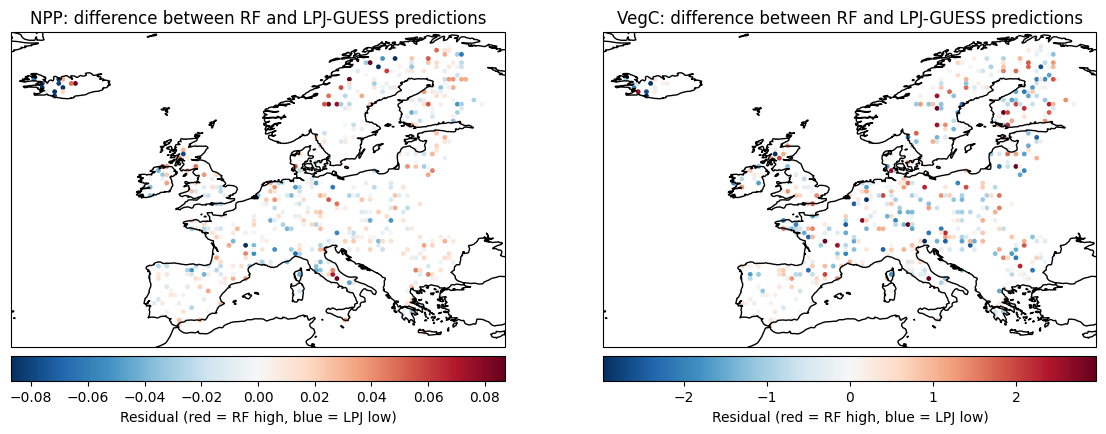

In [ ]:
# Get back the test rows with Land and Lon for plotting the residuals on a map
idx_reg_train, idx_reg_test = train_test_split(np.arange(europe_df.height), test_size=0.2, random_state=RANDOM_SEED)
reg_test_df = europe_df[idx_reg_test]
lon, lat = reg_test_df["Lon"].to_numpy(), reg_test_df["Lat"].to_numpy()

# Plot the residuals of the regression models on a map
fig, ax = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection=proj))
for ax, (name, model, ytr, yte) in zip(ax, targets):
    higher = model.predict(X_reg_test) - yte # If positive, RF is predicting higher than LPJ
    lim = np.quantile(np.abs(higher), 0.98) # Crop the colour values to outliers don't have too much power (visually)
    sc = ax.scatter(lon, lat, c=higher, s=6, cmap="RdBu_r", vmin=-lim, vmax=lim, transform=proj)
    ax.coastlines()
    ax.set_title(f"{name}: difference between RF and LPJ-GUESS predictions")
    plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.02, label="Residual (red = RF high, blue = LPJ low)")

plt.show()

### Extension 1

In [ ]:
# Evaluate the tuned multi-class model on the regression test rows
feat = multi_class_tuned.feature_names_in_.tolist()
biome_pred_train = multi_class_tuned.predict(X_train[feat])
biome_pred_test = multi_class_tuned.predict(X_test[feat])

biome_all = europe_df["Biome_obs_lpj"].cast(pl.Int32).to_numpy()
biome_train = biome_all[idx_reg_train]
biome_test = biome_all[idx_reg_test]

# Get the classes of the tuned multi-class model and the unique biomes in the dataset
classes = np.union1d(multi_class_tuned.classes_, biome_all)

print("Tuned biome model accuracy on the regression test rows:", accuracy_score(biome_test, biome_pred_test))

Tuned biome model accuracy on the regression test rows: 0.9318181818181818


In [ ]:
# Add biome information to the regression dataframes
def add_biome(X, biome):
    onehot = pd.get_dummies(pd.Categorical(biome, categories=classes), prefix="biome")
    return pd.concat([X.to_pandas().reset_index(drop=True), onehot], axis=1)

# Create three variants of the regression dataframes: one without biome information, one with observed biome information, and one with predicted biome information
variants = {"no biome": (X_reg_train.to_pandas(), X_reg_test.to_pandas()),
            "biome obs": (add_biome(X_reg_train, biome_train), add_biome(X_reg_test, biome_test)),
            "biome pred": (add_biome(X_reg_train, biome_pred_train), add_biome(X_reg_test, biome_pred_test))}

# Evaluate the regression models with and without biome information
rf_lpj_comp = []
for tname, ytr, yte in [("NPP", y_npp_train, y_npp_test), ("VegC", y_vegC_train, y_vegC_test)]:
    for vname, (Xtr, Xte) in variants.items():
        rf = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)
        rf.fit(Xtr, ytr)
        y_pred = rf.predict(Xte)
        rmse = np.sqrt(mean_squared_error(yte, y_pred))
        rf_lpj_comp.append({"target": tname,
                            "variant": vname,
                            "MSE": mean_squared_error(yte, y_pred),
                            "MAE": mean_absolute_error(yte, y_pred),
                            "train R2": r2_score(ytr, rf.predict(Xtr)),
                            "test R2": r2_score(yte, y_pred),
                            "RMSE": rmse})

display(pd.DataFrame(rf_lpj_comp).set_index(["target", "variant"]))

MSE       MAE  train R2   test R2      RMSE
target variant                                                     
NPP    no biome    0.000996  0.021459  0.984506  0.919614  0.031560
       biome obs   0.000843  0.019548  0.990364  0.932000  0.029027
       biome pred  0.000996  0.021517  0.984644  0.919576  0.031567
VegC   no biome    1.549597  0.907245  0.962789  0.768365  1.244828
       biome obs   1.474708  0.887593  0.964911  0.779560  1.214375
       biome pred  1.552334  0.907893  0.962787  0.767956  1.245927

### Extension 2

In [ ]:
# Evaluate the regression models with and without biome information, but only for biomes that have at least 30 observations in the training set
min_rows = 30

def per_biome_pred(global_model, Xtr, ytr, biome_tr, Xte, route_te):
    pred = global_model.predict(Xte) #start with the global model predictions
    for b in np.unique(biome_tr):
        tr, te = (biome_tr==b), (route_te==b)
        if tr.sum() >= min_rows and te.any():
            rf = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)
            rf.fit(Xtr[tr], ytr[tr])
            pred[te] = rf.predict(Xte[te])
    return pred

# turn the polars dataframes into pandas dataframes for compatibility
Xtr_pd, Xte_pd = X_reg_train.to_pandas(), X_reg_test.to_pandas()

# evaluate each model for each target (NPP and VegC) and each variant (no biome, biome obs, biome pred) and save the metrics per biome
per_biome_comp = []
for tname, gmodel, ytr, yte in [("NPP", model_reg_NPP, y_npp_train, y_npp_test), ("VegC", model_reg_VegC, y_vegC_train, y_vegC_test)]:
    cand = {"global model": gmodel.predict(Xte_pd)}
    for rname, route in [("per biome obs", biome_test), ("per biome pred", biome_pred_test)]:
        cand[rname] = per_biome_pred(gmodel, Xtr_pd, ytr, biome_train, Xte_pd, route)
    for mname, p in cand.items():
        rmse = np.sqrt(mean_squared_error(yte, p))
        per_biome_comp.append({"target": tname,
                            "model": mname,
                            "MSE": mean_squared_error(yte, p),
                            "MAE": mean_absolute_error(yte, p),
                            "test R2": r2_score(yte, p),
                            "RMSE": rmse})
display(pd.DataFrame(per_biome_comp).set_index(["target", "model"]))

MSE       MAE   test R2      RMSE
target model                                                 
NPP    global model    0.000996  0.021459  0.919614  0.031560
       per biome obs   0.000731  0.019488  0.941019  0.027033
       per biome pred  0.000811  0.020369  0.934583  0.028470
VegC   global model    1.549597  0.907245  0.768365  1.244828
       per biome obs   1.440181  0.883739  0.784721  1.200076
       per biome pred  1.579576  0.920243  0.763884  1.256812